# Crop & mask

Restrict a raster to an area of interest:

- **`crop(mask=vector)`** — clip to polygon geometry (everything outside becomes no-data).
- **`crop(bbox=..., epsg=...)`** — clip to a rectangular bounding box.
- **`get_mask()`** — the boolean valid-data mask (True where a cell holds real data).

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-ops-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

ds = Dataset.read_file(DATA / 'acc4000.tif')
polys = FeatureCollection.read_file(DATA / 'coello_polygons.geojson')
ds.shape, ds.epsg, (len(polys), polys.epsg)

((1, 13, 14), 32618, (4, 32618))

The full input raster — every cropped result below is a subset of this extent.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


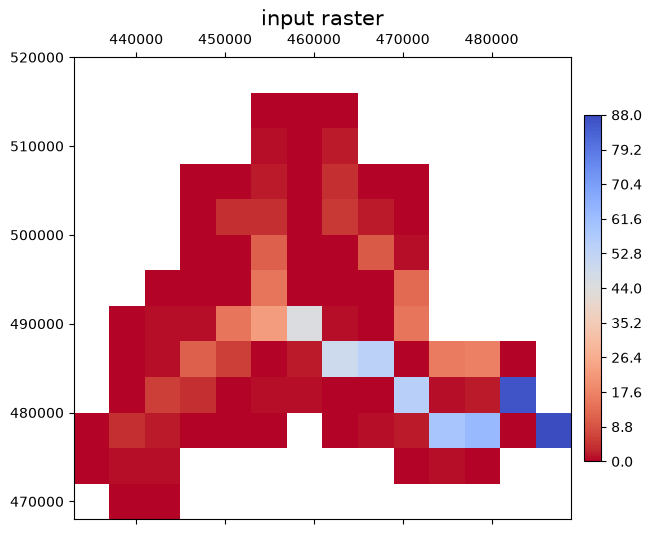

In [3]:
ds.plot(band=0, title="input raster")

## Crop to polygons — `crop(mask=...)`

The raster shrinks to the polygons' envelope; cells outside the polygons are set to no-data.

In [4]:
clipped = ds.crop(mask=polys)
clipped.shape, clipped.epsg

((1, 5, 8), 32618)

After the polygon crop the grid shrinks to the polygons' envelope and cells outside them are no-data.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


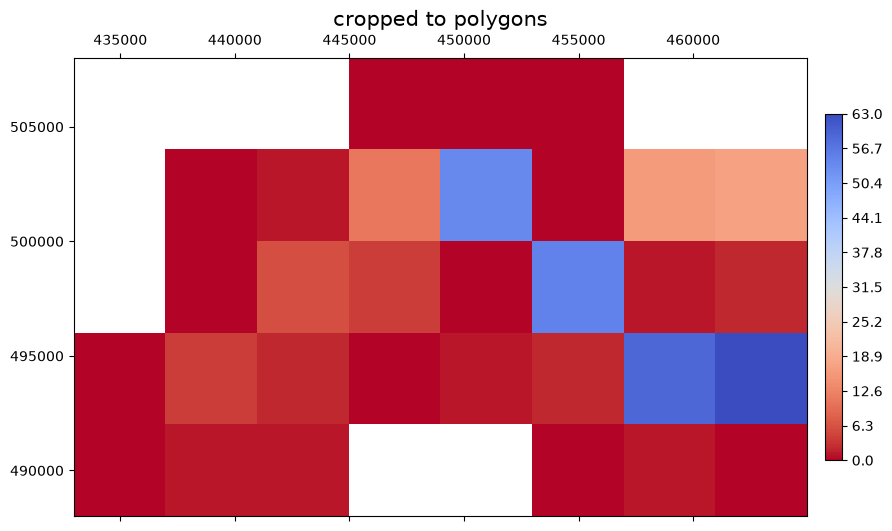

In [5]:
clipped.plot(band=0, title="cropped to polygons")

## Crop to a bounding box — `crop(bbox=...)`

Keep only the inner half of the raster's extent.

In [6]:
xmin, ymin, xmax, ymax = ds.bbox
dx, dy = (xmax - xmin) / 4, (ymax - ymin) / 4
inner = ds.crop(bbox=(xmin + dx, ymin + dy, xmax - dx, ymax - dy), epsg=ds.epsg)
inner.shape

(1, 7, 7)

The bbox crop keeps only the inner rectangle of the original extent.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


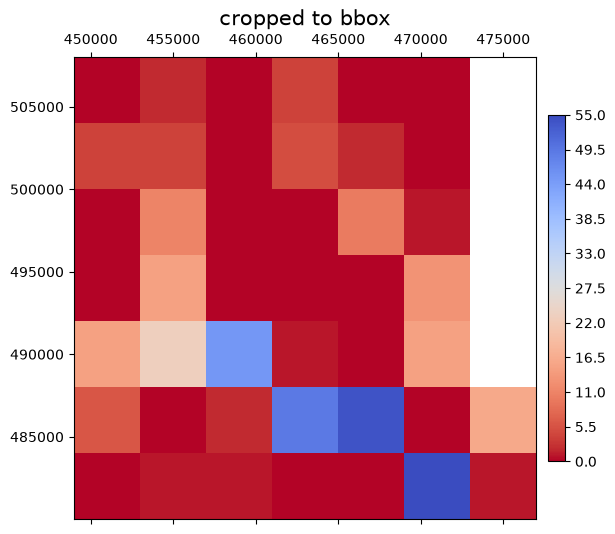

In [7]:
inner.plot(band=0, title="cropped to bbox")

## The valid-data mask — `get_mask`

A GDAL-style mask: **nonzero (255)** where the cell holds data, **0** where it is no-data.

In [8]:
mask = ds.get_mask()
valid = int((mask > 0).sum())
mask.shape, valid, 'valid of', mask.size

((13, 14), 89, 'valid of', 182)

## Notes

- `crop` accepts a `FeatureCollection` or a GeoDataFrame as the mask; pass `touch=False` to
  keep only cells whose centre falls inside the geometry.
- See also: [Reproject / resample / align](reproject-resample-align.ipynb),
  [Zonal statistics](zonal-statistics.ipynb).